# Dự đoán và phân tích doanh thu concert

## I. Giới thiệu dự án

Dự án này áp dụng các kỹ thuật **machine learning** để phân tích và dự đoán doanh thu (revenue) của các buổi concert dựa trên dữ liệu lịch sử.

Phân tích tập trung vào hai mục tiêu chính:

### 1. Predictive Modeling — Mô hình Dự đoán
- Dự đoán chính xác doanh thu concert dựa trên các biến vận hành và hành vi bán vé.

### 2. Explanatory Modeling — Mô hình Giải thích
- Xác định các yếu tố cấu trúc và bối cảnh rộng hơn liên quan đến sự khác biệt doanh thu giữa các concert.

Dataset bao gồm thông tin về doanh thu, lượng vé, hành vi khán giả, tour diễn và đặc điểm thị trường theo khu vực địa lý.


## Tiền xử lý

In [31]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from pathlib import Path


In [32]:
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == 'notebooks'
    else Path.cwd()
)

DATA_DIR = PROJECT_ROOT / 'data'

# Read dataset
cleaned_path = DATA_DIR / 'cleaned_data.csv'

df = pd.read_csv(cleaned_path)

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]:,}')

display(df.head())

Rows: 406
Columns: 12


,City,Country,Venue,Opening act(s),Revenue,Tour,Tickets sold,Tickets available,Tickets remaining,Number of opening acts,Capacity utilization,Average ticket price
0,Evansville,United States,Roberts Municipal Stadium,Gloriana and Kellie Pickler,360617.0,Fearless Tour,7463.0,7463.0,0.0,2,1.0,48.320649
1,Jonesboro,United States,Convocation Center,Gloriana and Kellie Pickler,340328.0,Fearless Tour,7822.0,7822.0,0.0,2,1.0,43.509077
2,St. Louis,United States,Scottrade Center,Gloriana and Kellie Pickler,650420.0,Fearless Tour,13764.0,13764.0,0.0,2,1.0,47.255158
3,North Charleston,United States,North Charleston Coliseum,Gloriana and Kellie Pickler,398154.0,Fearless Tour,8751.0,8751.0,0.0,2,1.0,45.498115
4,Jacksonville,United States,Jacksonville Veterans Memorial Arena,Gloriana and Kellie Pickler,507012.0,Fearless Tour,11072.0,11072.0,0.0,2,1.0,45.792269


In [33]:
ml_df = df.copy()

print("Dataset Shape:", ml_df.shape)
ml_df.head()

Dataset Shape: (406, 12)


,City,Country,Venue,Opening act(s),Revenue,Tour,Tickets sold,Tickets available,Tickets remaining,Number of opening acts,Capacity utilization,Average ticket price
0,Evansville,United States,Roberts Municipal Stadium,Gloriana and Kellie Pickler,360617.0,Fearless Tour,7463.0,7463.0,0.0,2,1.0,48.320649
1,Jonesboro,United States,Convocation Center,Gloriana and Kellie Pickler,340328.0,Fearless Tour,7822.0,7822.0,0.0,2,1.0,43.509077
2,St. Louis,United States,Scottrade Center,Gloriana and Kellie Pickler,650420.0,Fearless Tour,13764.0,13764.0,0.0,2,1.0,47.255158
3,North Charleston,United States,North Charleston Coliseum,Gloriana and Kellie Pickler,398154.0,Fearless Tour,8751.0,8751.0,0.0,2,1.0,45.498115
4,Jacksonville,United States,Jacksonville Veterans Memorial Arena,Gloriana and Kellie Pickler,507012.0,Fearless Tour,11072.0,11072.0,0.0,2,1.0,45.792269


## II. Feature Engineering

**Feature engineering** được thực hiện nhằm cải thiện hiệu suất mô hình và tăng khả năng diễn giải theo góc độ kinh doanh.

Một số biến mới được tạo ra để nắm bắt hành vi tham dự và đặc điểm cấu trúc của concert. Các biến được tạo ra dưới đây nhằm cung cấp thêm thông tin ngoài dữ liệu thô ban đầu.

### FEATURE ENGINEERING

#### Giải thích các biến được tạo ra

**1. `Attendance_Rate`** *(Tỷ lệ lấp đầy)*

Biến này được lấy trực tiếp từ cột `Capacity utilization` có sẵn trong dữ liệu — thể hiện tỷ lệ phần trăm số ghế được lấp đầy so với sức chứa tối đa của venue. Giá trị bằng 1.0 nghĩa là concert sold out hoàn toàn. Lý do tạo biến: đây là chỉ số quan trọng phản ánh **mức độ nhu cầu khán giả** đối với một show diễn — một concert dù venue lớn nhưng chỉ lấp đầy 60% sẽ có hành vi doanh thu khác hẳn so với một concert sold out.

**2. `Attendance_Level`** *(Phân loại mức cầu khán giả)*

Biến phân loại (categorical) được tạo ra từ `Attendance_Rate` theo ba mức:
- `Low Demand`: tỷ lệ lấp đầy < 70%
- `Moderate Demand`: tỷ lệ lấp đầy 70% – 90%
- `High Demand`: tỷ lệ lấp đầy ≥ 90%

Lý do tạo biến: thay vì dùng tỷ lệ liên tục, phân loại theo mức giúp mô hình nắm bắt được **ngưỡng hành vi** — sự khác biệt giữa show gần sold out và show thực sự sold out hoàn toàn có thể không tuyến tính.

**3. `Region`** *(Khu vực địa lý)*

Biến này nhóm cột `Country` thành các khu vực lớn:
- `North America`: Mỹ, Canada
- `Europe`: Pháp, Đức, Anh
- `Asia-Pacific`: Nhật Bản, Singapore, Úc
- `Other`: các quốc gia còn lại

Lý do tạo biến: số lượng quốc gia trong dữ liệu quá nhiều để đưa trực tiếp vào model, nhưng **đặc điểm thị trường theo khu vực địa lý** (sức mua, cầu vé, giá vé) có xu hướng tương đồng trong cùng một vùng. Nhóm hóa giúp giảm chiều dữ liệu và tạo ra feature có ý nghĩa kinh doanh rõ ràng hơn.

In [34]:
# Attendance Rate
ml_df['Attendance_Rate'] = (ml_df['Capacity utilization'] )
ml_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Attendance Level
def attendance_level(rate):
    if rate < 0.7:
        return 'Low Demand'
    elif rate < 0.9:
        return 'Moderate Demand'
    else:
        return 'High Demand'

ml_df['Attendance_Level'] = (
    ml_df['Attendance_Rate']
    .apply(attendance_level)
)

# Region Grouping
region_map = {
    'USA': 'North America',
    'Canada': 'North America',

    'France': 'Europe',
    'Germany': 'Europe',
    'UK': 'Europe',

    'Japan': 'Asia-Pacific',
    'Singapore': 'Asia-Pacific',
    'Australia': 'Asia-Pacific'
}

ml_df['Region'] = (
    ml_df['Country']
    .map(region_map)
)

# Fill missing regions as Other
ml_df['Region'] = ml_df['Region'].fillna('Other')

### Feature Selection

#### Đề xuất sử dụng 2 model

Ở bước này, hai bộ feature riêng biệt được xây dựng để phục vụ hai mục tiêu phân tích khác nhau:

**Model 1 — Predictive Model (Mô hình Dự đoán):** bao gồm tất cả các biến liên quan đến vé và hành vi tham dự — `Tickets sold`, `Tickets available`, `Attendance_Rate`, `Tour`, `Region`, `Attendance_Level`. Mục tiêu là **tối đa hóa độ chính xác dự đoán** doanh thu.

**Model 2 — Explanatory Model (Mô hình Giải thích):** loại bỏ các biến trực tiếp liên quan đến giá vé và số lượng vé (`Tickets sold`, `Tickets available`), chỉ giữ lại `Attendance_Rate`, `Tour`, `Region`, `Attendance_Level`. Mục tiêu là **hiểu các yếu tố cấu trúc** ảnh hưởng đến doanh thu — tour identity, khu vực địa lý, mức độ cầu khán giả.

Lý do cần 2 model: nếu chỉ chạy một model duy nhất bao gồm cả `Tickets sold`, model sẽ bị "lấn át" bởi biến này vì số vé bán ra gần như quyết định hoàn toàn doanh thu (r = 0.95 theo EDA). Điều đó khiến các yếu tố kinh doanh quan trọng khác như **thương hiệu tour, thị trường địa lý, mức độ cầu** bị mờ đi trong phân tích.

In [35]:
# MODEL 1: PREDICTIVE MODEL
predictive_features = [
    'Tickets sold',
    'Tickets available',
    'Attendance_Rate',
    'Tour',
    'Region',
    'Attendance_Level']

# MODEL 2: EXPLANATORY MODEL
explanatory_features = [
    'Attendance_Rate',
    'Tour',
    'Region',
    'Attendance_Level'
    ]

# CREATE FEATURE MATRICES
X_pred = ml_df[predictive_features]
X_exp = ml_df[explanatory_features]

# Target variable
y = ml_df['Revenue']

# LOG TRANSFORMATION
y_log = np.log1p(y)

print("Original Revenue Skewness:", y.skew())
print("Log Revenue Skewness:", y_log.skew())

# HANDLE CATEGORICAL VARIABLES
X_pred = pd.get_dummies(
    X_pred,
    drop_first=True
)

X_exp = pd.get_dummies(
    X_exp,
    drop_first=True
)

# TRAIN-TEST SPLIT
X_train_pred, X_test_pred, y_train_pred, y_test_pred = train_test_split(
    X_pred,
    y_log,
    test_size=0.2,
    random_state=42
)

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp,
    y_log,
    test_size=0.2,
    random_state=42
)

# FEATURE SCALING
scaler_pred = StandardScaler()
scaler_exp = StandardScaler()

X_train_pred_scaled = scaler_pred.fit_transform(X_train_pred)
X_test_pred_scaled = scaler_pred.transform(X_test_pred)

X_train_exp_scaled = scaler_exp.fit_transform(X_train_exp)
X_test_exp_scaled = scaler_exp.transform(X_test_exp)

# FINAL OUTPUT CHECK

print("PREPROCESSING COMPLETED")

print("\nPredictive Model Shape:")
print(X_train_pred_scaled.shape)

print("\nExplanatory Model Shape:")
print(X_train_exp_scaled.shape)

print("\nTarget Variable Shape:")
print(y_log.shape)

print("\nPredictive Features:")
print(X_pred.columns.tolist())

print("\nExplanatory Features:")
print(X_exp.columns.tolist())

Original Revenue Skewness: 1.3861715826054164
Log Revenue Skewness: 0.44250431593070494
PREPROCESSING COMPLETED

Predictive Model Shape:
(324, 12)

Explanatory Model Shape:
(324, 10)

Target Variable Shape:
(406,)

Predictive Features:
['Tickets sold', 'Tickets available', 'Attendance_Rate', 'Tour_Reputation Stadium Tour', 'Tour_Speak Now World Tour', 'Tour_The 1989 World Tour', 'Tour_The Red Tour', 'Region_Europe', 'Region_North America', 'Region_Other', 'Attendance_Level_Low Demand', 'Attendance_Level_Moderate Demand']

Explanatory Features:
['Attendance_Rate', 'Tour_Reputation Stadium Tour', 'Tour_Speak Now World Tour', 'Tour_The 1989 World Tour', 'Tour_The Red Tour', 'Region_Europe', 'Region_North America', 'Region_Other', 'Attendance_Level_Low Demand', 'Attendance_Level_Moderate Demand']


## III. Predictive Modeling — Mô hình Dự đoán

Phương pháp modeling đầu tiên tập trung vào **tối đa hóa độ chính xác dự đoán** doanh thu concert.

Model này bao gồm các biến vận hành như số vé bán ra và các chỉ số liên quan đến tham dự. Nhiều thuật toán machine learning được đánh giá và so sánh để xác định model có hiệu suất tốt nhất.

### Huấn luyện mô hình

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import ( RandomizedSearchCV, cross_val_score)
from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score )
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

### Xây dựng pipeline cho mô hình

#### Pipeline hồi quy tuyến tính

In [37]:
pipeline_lr = Pipeline([ ("model", LinearRegression()) ])

#### Pipeline Random Forest

In [38]:
pipeline_rf = Pipeline([ ("model", RandomForestRegressor( random_state=42 )) ])

### Huấn luyện mô hình hồi quy tuyến tính

In [39]:
pipeline_lr.fit( X_train_pred_scaled, y_train_pred ) 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Đánh giá mô hình hồi quy tuyến tính

In [40]:
y_pred_lr = pipeline_lr.predict(
    X_test_pred_scaled
)

In [41]:
mae_lr = mean_absolute_error( y_test_pred, y_pred_lr )
rmse_lr = np.sqrt( mean_squared_error( y_test_pred, y_pred_lr ) ) 
r2_lr = r2_score( y_test_pred, y_pred_lr )

print("===================================") 
print("LINEAR REGRESSION RESULTS") 
print("===================================") 
print(f"MAE : {mae_lr:.4f}") 
print(f"RMSE : {rmse_lr:.4f}") 
print(f"R² : {r2_lr:.4f}")


LINEAR REGRESSION RESULTS
MAE : 0.2168
RMSE : 0.3813
R² : 0.8321


### Tinh chỉnh siêu tham số cho Random Forest

In [42]:
# Define parameter grid for Random Forest
param_dist_rf = { "model__n_estimators": [50, 100, 200], "model__max_depth": [ None, 5, 10 ], "model__min_samples_split": [ 2, 5, 10 ], "model__min_samples_leaf": [ 1, 2, 4 ] }

# Randomized Search
random_search_rf = RandomizedSearchCV( estimator=pipeline_rf, param_distributions=param_dist_rf, n_iter=10, cv=5, scoring='r2', random_state=42, n_jobs=-1 )

# Train tuned Random Forest
random_search_rf.fit( X_train_pred_scaled, y_train_pred )

# Best Model
best_rf = random_search_rf.best_estimator_

print("BEST RANDOM FOREST PARAMETERS")  
print(random_search_rf.best_params_)


BEST RANDOM FOREST PARAMETERS
{'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': None}


### Kết quả dự đoán của Random Forest

In [43]:
y_pred_rf = best_rf.predict( X_test_pred_scaled )

### Đánh giá mô hình Random Forest


In [44]:
mae_rf = mean_absolute_error( y_test_pred, y_pred_rf ) 
rmse_rf = np.sqrt( mean_squared_error( y_test_pred, y_pred_rf ) ) 
r2_rf = r2_score( y_test_pred, y_pred_rf ) 

print("RANDOM FOREST RESULTS") 
print(f"MAE : {mae_rf:.4f}") 
print(f"RMSE : {rmse_rf:.4f}") 
print(f"R² : {r2_rf:.4f}")

RANDOM FOREST RESULTS
MAE : 0.1281
RMSE : 0.2017
R² : 0.9530


### Kiểm định chéo

In [45]:
cv_scores_rf = cross_val_score( best_rf, X_train_pred_scaled, y_train_pred, cv=5, scoring='r2' ) 

print("CROSS VALIDATION RESULTS") 
print("CV R² Scores:", cv_scores_rf) 
print("Average CV R²:", cv_scores_rf.mean())

CROSS VALIDATION RESULTS
CV R² Scores: [0.96898916 0.95105529 0.9835893  0.96782666 0.91167963]
Average CV R²: 0.956628009476723


### So sánh mô hình

In [46]:
comparison_df = pd.DataFrame({ 'Model': [ 'Linear Regression', 'Random Forest' ], 'MAE': [ mae_lr, mae_rf ], 'RMSE': [ rmse_lr, rmse_rf ], 'R²': [ r2_lr, r2_rf ] }) 

print("MODEL COMPARISON") 
print(comparison_df)

MODEL COMPARISON
               Model       MAE      RMSE        R²
0  Linear Regression  0.216772  0.381301  0.832132
1      Random Forest  0.128143  0.201709  0.953023


## IV. Diễn giải mô hình dự đoán

**Random Forest** đạt hiệu suất dự đoán mạnh hơn so với **Linear Regression**, cho thấy sự tồn tại của các mối quan hệ **phi tuyến tính (nonlinear)** trong dữ liệu doanh thu concert.

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 0.2168 | 0.3813 | 0.8321 |
| **Random Forest** | **0.1281** | **0.2017** | **0.9530** |

Kết quả cho thấy các biến liên quan đến vé và tham dự là những **predictor** rất hiệu quả cho doanh thu concert. Kết quả **cross-validation** (Average CV R² ≈ 0.957) cũng xác nhận rằng model có khả năng **tổng quát hóa (generalize)** tốt trên các tập dữ liệu con khác nhau.

### Mức độ quan trọng của đặc trưng

In [47]:
# Extract feature importance 
feature_importance = pd.DataFrame({ 'Feature': X_pred.columns, 'Importance': best_rf.named_steps[ 'model' ].feature_importances_ })
# Sort descending
feature_importance = ( feature_importance .sort_values( by='Importance', ascending=False ) ) 

print("FEATURE IMPORTANCE") 
print(feature_importance.head(10))

FEATURE IMPORTANCE
                        Feature  Importance
1             Tickets available    0.464909
0                  Tickets sold    0.445903
5      Tour_The 1989 World Tour    0.043732
6             Tour_The Red Tour    0.018267
4     Tour_Speak Now World Tour    0.011232
9                  Region_Other    0.009943
3  Tour_Reputation Stadium Tour    0.003723
7                 Region_Europe    0.001133
8          Region_North America    0.000705
2               Attendance_Rate    0.000298


### Biểu diễn trực quan độ quan trọng của đặc trưng

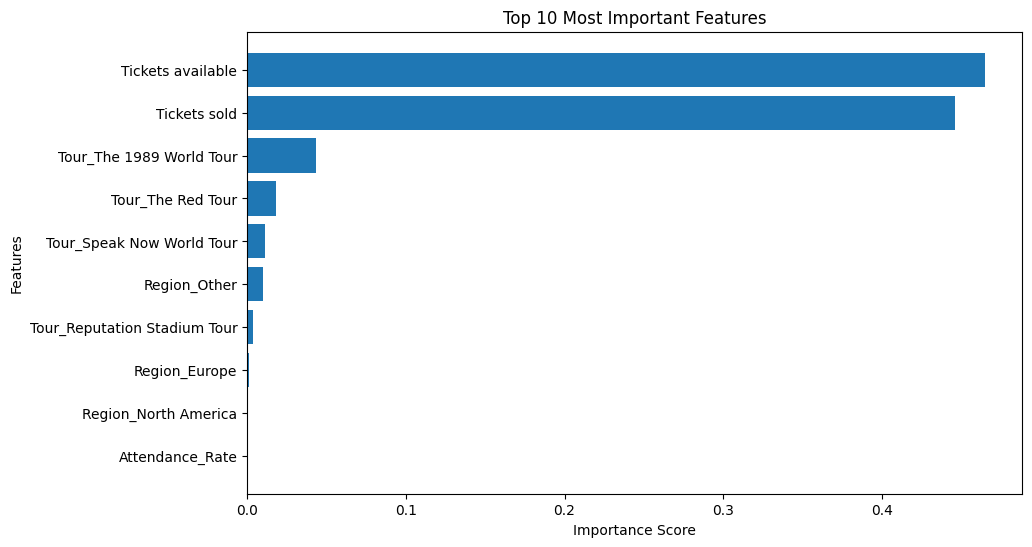

In [48]:
top_features = feature_importance.head(10) 
plt.figure(figsize=(10,6)) 
plt.barh( top_features['Feature'], top_features['Importance'] ) 
plt.xlabel("Importance Score") 
plt.ylabel("Features") 
plt.title( "Top 10 Most Important Features" ) 
plt.gca().invert_yaxis() 
plt.show()

### Biểu diễn trực quan giữa giá trị thực tế và giá trị dự đoán

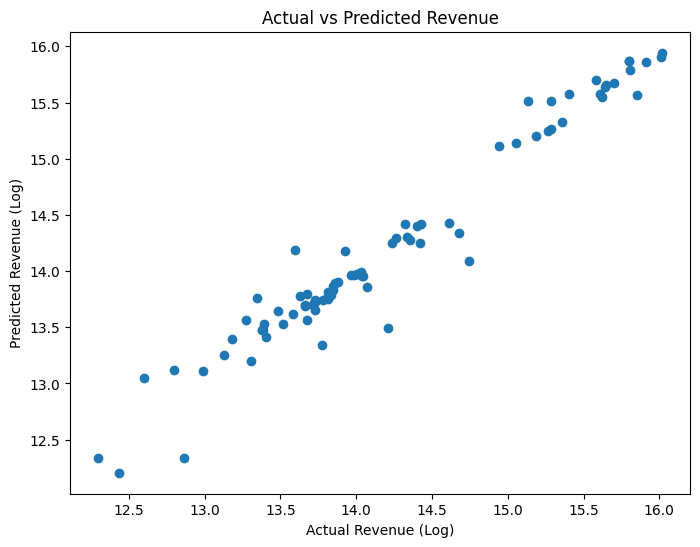

In [49]:
plt.figure(figsize=(8,6)) 
plt.scatter( y_test_pred, y_pred_rf ) 
plt.xlabel("Actual Revenue (Log)") 
plt.ylabel("Predicted Revenue (Log)") 
plt.title( "Actual vs Predicted Revenue" ) 
plt.show()

### DIỄN GIẢI KINH DOANH

Mô hình Random Forest đạt hiệu suất dự đoán tốt hơn Linear Regression, cho thấy doanh thu concert có xu hướng chứa các mối quan hệ phi tuyến tính.
Các biến liên quan đến vé vẫn là những yếu tố dự đoán doanh thu quan trọng nhất.
Đặc điểm của tour diễn và sự khác biệt giữa các thị trường khu vực cũng góp phần tạo ra biến động doanh thu.
Kết quả cross-validation cho thấy mô hình có khả năng khái quát hóa tương đối tốt trên các tập dữ liệu khác nhau.
Các phát hiện cho thấy cả chiến lược định giá và nhu cầu khán giả đều đóng vai trò quan trọng trong việc tạo ra doanh thu concert.

## V.  Chuyển tiếp sang mô hình giải thích

Mặc dù các **predictive model** đạt độ chính xác cao, các biến liên quan trực tiếp đến vé (như `Tickets sold`, `Tickets available`) có thể **chi phối** quá trình dự đoán vì chúng gắn kết trực tiếp với việc tạo ra doanh thu.

Để hiểu rõ hơn **các động lực kinh doanh rộng hơn**, một phương pháp modeling thứ hai được xây dựng. Các biến định giá trực tiếp được loại bỏ nhằm khảo sát ảnh hưởng của các yếu tố **cấu trúc và bối cảnh** như tour identity, hành vi tham dự và đặc điểm thị trường khu vực địa lý.

## VI. Mô hình hóa giải thích 

Các **explanatory model** nhằm xác định các yếu tố liên quan đến sự khác biệt doanh thu giữa các concert, đồng thời giảm thiểu ảnh hưởng của các biến định giá trực tiếp.

Phương pháp này chú trọng hơn vào **diễn giải kinh doanh (business interpretation)** thay vì tối đa hóa độ chính xác dự đoán.

> Goal: Identify structural factors affecting concert revenue differences. 
Direct revenue-related variables are removed to uncover broader business patterns.

### Tạo tập đặc trưng giải thích

In [50]:
explanatory_features = [ 'Attendance_Rate', 'Tour', 'Region', 'Attendance_Level' ] 
X_exp = ml_df[explanatory_features] # One-hot encoding 
X_exp = pd.get_dummies( X_exp, drop_first=True ) 
print("Explanatory Dataset Shape:") 
print(X_exp.shape)

Explanatory Dataset Shape:
(406, 10)


### Tách dữ liệu train-test


In [51]:
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split( X_exp, y_log, test_size=0.2, random_state=42 )

### Chuẩn hóa đặc trưng


In [52]:
scaler_exp = StandardScaler() 
X_train_exp_scaled = scaler_exp.fit_transform( X_train_exp ) 
X_test_exp_scaled = scaler_exp.transform( X_test_exp )

### Xây dựng Pipelines

In [53]:
pipeline_lr_exp = Pipeline([ ("model", LinearRegression()) ]) 
pipeline_rf_exp = Pipeline([ ("model", RandomForestRegressor( random_state=42 )) ])

### Huấn luyện mô hình hồi quy tuyến tính

In [54]:
pipeline_lr_exp.fit( X_train_exp_scaled, y_train_exp ) 
y_pred_lr_exp = pipeline_lr_exp.predict( X_test_exp_scaled )

### Đánh giá mô hình hồi quy tuyến tính

In [55]:
r2_lr_exp = r2_score( y_test_exp, y_pred_lr_exp ) 
 
print("EXPLANATORY LINEAR REGRESSION") 
print(f"R²: {r2_lr_exp:.4f}")

EXPLANATORY LINEAR REGRESSION
R²: 0.6115


### Huấn luyện Random Forest

In [56]:
pipeline_rf_exp.fit( X_train_exp_scaled, y_train_exp ) 
y_pred_rf_exp = pipeline_rf_exp.predict( X_test_exp_scaled )

### Đánh giá Random Forest

In [57]:
r2_rf_exp = r2_score( y_test_exp, y_pred_rf_exp ) 

print("EXPLANATORY RANDOM FOREST") 
print(f"R²: {r2_rf_exp:.4f}")

EXPLANATORY RANDOM FOREST
R²: 0.6214


### Mức độ quan trọng của các đặc trưng

In [58]:
feature_importance_exp = pd.DataFrame({ 'Feature': X_exp.columns, 'Importance': pipeline_rf_exp.named_steps[ 'model' ].feature_importances_ }) 
feature_importance_exp = ( feature_importance_exp .sort_values( by='Importance', ascending=False ) ) 

print("\n===================================") 
print("EXPLANATORY FEATURE IMPORTANCE") 
print("===================================") 
print(feature_importance_exp)


EXPLANATORY FEATURE IMPORTANCE
                            Feature  Importance
1      Tour_Reputation Stadium Tour    0.525067
3          Tour_The 1989 World Tour    0.253247
4                 Tour_The Red Tour    0.101209
7                      Region_Other    0.025442
2         Tour_Speak Now World Tour    0.024590
5                     Region_Europe    0.023665
0                   Attendance_Rate    0.019326
8       Attendance_Level_Low Demand    0.012957
6              Region_North America    0.011331
9  Attendance_Level_Moderate Demand    0.003165


### Trực quan hóa

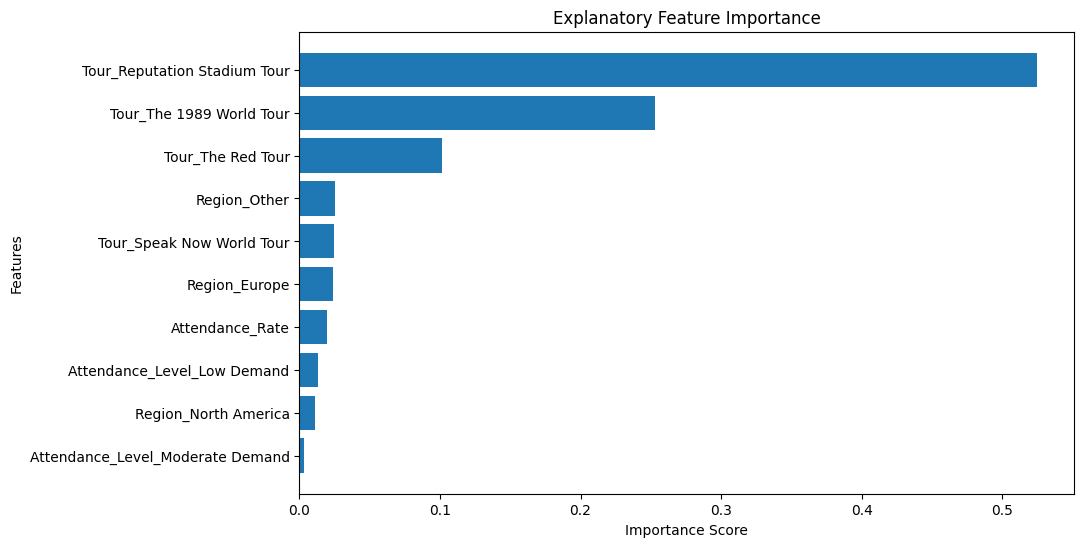

In [59]:
top_exp_features = feature_importance_exp.head(10) 
plt.figure(figsize=(10,6)) 
plt.barh( top_exp_features['Feature'], top_exp_features['Importance'] ) 
plt.xlabel("Importance Score") 
plt.ylabel("Features") 
plt.title( "Explanatory Feature Importance" ) 
plt.gca().invert_yaxis() 
plt.show()

## VII. Diễn giải mô hình giải thích

Các **explanatory model** đạt hiệu suất dự đoán ở mức trung bình, cho thấy các biến cấu trúc và bối cảnh vẫn giải thích được một phần đáng kể sự biến động của doanh thu.

| Model | R² |
|---|---|
| Linear Regression | 0.6115 |
| **Random Forest** | **0.6214** |

Phân tích **feature importance** cho thấy **tour identity** đóng vai trò lớn nhất trong việc phân biệt kết quả doanh thu giữa các concert. Phát hiện này làm nổi bật tầm quan trọng của **thương hiệu, nhu cầu khán giả và độ phổ biến của tour** trong ngành giải trí trực tiếp (live entertainment).

**Hành vi tham dự và đặc điểm khu vực địa lý** cũng đóng góp vào sự biến động doanh thu, mặc dù mức độ ảnh hưởng nhỏ hơn so với tour identity.

## VIII. Những hạn chế

Một số hạn chế cần được thừa nhận trong phân tích này:

- **Quy mô dataset còn hạn chế** — số lượng quan sát tương đối ít có thể ảnh hưởng đến độ ổn định của model.
- **Thiếu các biến bên ngoài** — các yếu tố như chiến dịch marketing, mức độ tương tác mạng xã hội và điều kiện kinh tế vĩ mô không được đưa vào phân tích.
- **Dữ liệu lịch sử** — phân tích dựa trên dữ liệu lịch sử và có thể không nắm bắt đầy đủ sự thay đổi trong hành vi khán giả theo thời gian.

Các nghiên cứu trong tương lai có thể bổ sung thêm các biến hành vi và thị trường để cải thiện khả năng giải thích và độ chính xác dự đoán.

## IX. Kết luận

Dự án đã xây dựng thành công hai hướng phân tích bổ trợ nhau cho bài toán doanh thu concert:

**1. Predictive Model:** Random Forest vượt trội Linear Regression với R² = 0.953, cho thấy mối quan hệ phi tuyến tính trong dữ liệu. Số vé bán ra (`Tickets sold`, `Tickets available`) là các **predictor** mạnh nhất — phản ánh thực tế rằng quy mô venue là đòn bẩy doanh thu cốt lõi.

**2. Explanatory Model:** Khi loại bỏ các biến vé, **tour identity** nổi lên là yếu tố cấu trúc quan trọng nhất. Điều này xác nhận rằng thương hiệu tour, chiến lược định giá và mức độ nổi tiếng của nghệ sĩ đóng vai trò quyết định trong việc tạo ra sự khác biệt doanh thu giữa các concert.

Hai model cùng nhau cung cấp góc nhìn toàn diện: **dự đoán chính xác** cho các quyết định vận hành ngắn hạn, và **hiểu biết chiến lược** cho các quyết định kinh doanh dài hạn trong ngành live entertainment.